# Object Counting: Coin Detection, Denomination Classification, and Total Value
## Activity 3 — Object Counting (Coins)

This notebook:
1. Detects coins in an image using the **Hough Circle Transform**
2. Classifies each detected coin's **denomination** based on its relative **size** and **color pattern** (monometallic vs. bi-metallic, silver vs. gold tone)
3. Computes the **total peso value** of all detected coins

Make sure the image file (`coins.jpg`) is in the same folder as this notebook, or update `IMAGE_PATH` below.

> **Note:** The classification thresholds below (`BIMETALLIC_CHROMA_DIFF`, `GOLD_CHROMA_THRESHOLD`, `SENTIMO_RADIUS_MAX`, etc.) are calibrated for Philippine coins (1 piso, 5 piso, 10 piso, 20 piso, 25 sentimo) photographed together at the same distance. If you use a different photo, angle, or lighting, you may need to adjust these values — see Section 4.

## Dependencies
Run the cell below once to install the required packages.

In [13]:
# Run this once if the packages are not yet installed
!pip install opencv-python numpy matplotlib

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE_PATH = 'coins.jpg'  # change this if your image has a different filename

## 1. Load and Preview the Image

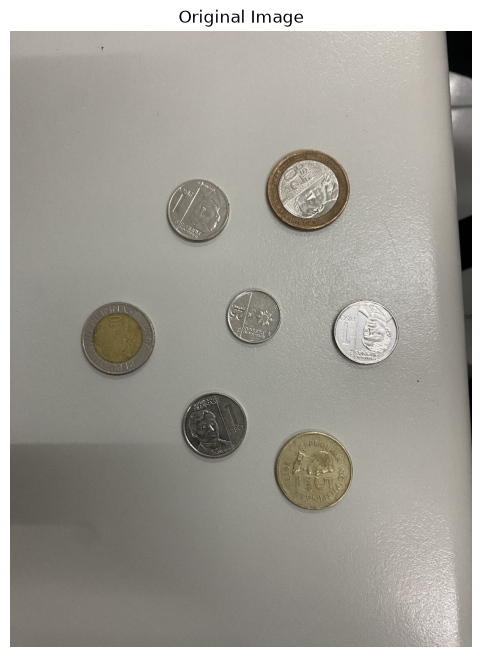

In [15]:
image = cv2.imread(IMAGE_PATH)

if image is None:
    raise FileNotFoundError(f"Could not load '{IMAGE_PATH}'. Make sure the file is in the working directory.")

# Resize for faster processing (optional, keeps aspect ratio)
scale = 0.25
image = cv2.resize(image, (0, 0), fx=scale, fy=scale)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(image_rgb)
plt.title('Original Image')
plt.axis('off')
plt.show()

## 2. Detect Circles (Hough Circle Transform)

In [16]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.medianBlur(gray, 7)

circles = cv2.HoughCircles(
    blurred,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=60,
    param1=80,
    param2=40,
    minRadius=30,
    maxRadius=90
)

if circles is not None:
    circles = np.round(circles[0, :]).astype("int")
    print(f"Circles detected: {len(circles)}")
else:
    circles = np.array([])
    print("No circles detected. Try adjusting the Hough parameters above.")

Circles detected: 7


## 3. Classify Each Coin's Denomination

For each detected coin, we sample the average color of two regions:
- **Center** (inner 40% of the radius)
- **Ring** (outer 70%–95% of the radius)

We then compute the **chroma** of each region — `max(R,G,B) - min(R,G,B)` — which is low for neutral/silver tones and high for warm/gold tones.

- If the center and ring have very different chroma (one clearly gold, one clearly silver) → the coin is **bi-metallic** (10 piso or 20 piso). Whichever bi-metallic coin has the **largest radius** is the 20 piso; the other is 10 piso.
- If the coin is **monometallic** (uniform color) and has an overall **golden** tone → **5 piso**.
- If the coin is monometallic and **silver/neutral**, its radius decides: the **smallest** coin is **25 sentimo**, the rest are **1 piso**.

In [17]:
def chroma(rgb_color):
    r, g, b = rgb_color
    return max(r, g, b) - min(r, g, b)

def get_region_color(img, x, y, r, r1_frac, r2_frac):
    """Mean RGB color within an annulus/disc: inner radius r1_frac*r to outer radius r2_frac*r."""
    mask = np.zeros(img.shape[:2], dtype=np.uint8)
    cv2.circle(mask, (x, y), int(r * r2_frac), 255, -1)
    if r1_frac > 0:
        cv2.circle(mask, (x, y), int(r * r1_frac), 0, -1)
    return cv2.mean(img, mask=mask)[:3]

# --- Tunable thresholds (calibrated for this coin set) ---
BIMETALLIC_CHROMA_DIFF = 15   # min chroma difference between center & ring to call it bi-metallic
BIMETALLIC_MIN_CHROMA = 25    # at least one region must be this golden to count as bi-metallic
GOLD_CHROMA_THRESHOLD = 25    # avg chroma above this = monometallic gold coin (5 piso)
SENTIMO_RADIUS_MAX = 48       # radius at/below this (and silver) = 25 sentimo

DENOM_VALUES = {'20 piso': 20, '10 piso': 10, '5 piso': 5, '1 piso': 1, '25 sentimo': 0.25}

all_radii = [c[2] for c in circles]
max_r = max(all_radii) if len(all_radii) else 0

coin_results = []
for (x, y, r) in circles:
    center_c = get_region_color(image_rgb, x, y, r, 0, 0.4)
    ring_c   = get_region_color(image_rgb, x, y, r, 0.7, 0.95)
    c_chroma = chroma(center_c)
    r_chroma = chroma(ring_c)

    bimetallic = (abs(c_chroma - r_chroma) > BIMETALLIC_CHROMA_DIFF and
                  max(c_chroma, r_chroma) > BIMETALLIC_MIN_CHROMA)

    if bimetallic:
        denom = '20 piso' if r == max_r else '10 piso'
    else:
        avg_chroma = (c_chroma + r_chroma) / 2
        if avg_chroma > GOLD_CHROMA_THRESHOLD:
            denom = '5 piso'
        elif r <= SENTIMO_RADIUS_MAX:
            denom = '25 sentimo'
        else:
            denom = '1 piso'

    coin_results.append({'x': x, 'y': y, 'r': r, 'denom': denom, 'value': DENOM_VALUES[denom]})

for c in coin_results:
    print(f"pos=({c['x']},{c['y']}) r={c['r']} -> {c['denom']} (PHP {c['value']})")

pos=(177,502) r=59 -> 10 piso (PHP 10)
pos=(487,260) r=67 -> 20 piso (PHP 20)
pos=(496,721) r=63 -> 5 piso (PHP 5)
pos=(334,643) r=51 -> 1 piso (PHP 1)
pos=(398,467) r=46 -> 25 sentimo (PHP 0.25)
pos=(581,491) r=50 -> 1 piso (PHP 1)
pos=(307,290) r=51 -> 1 piso (PHP 1)


## 4. Annotate, Count, and Total the Value

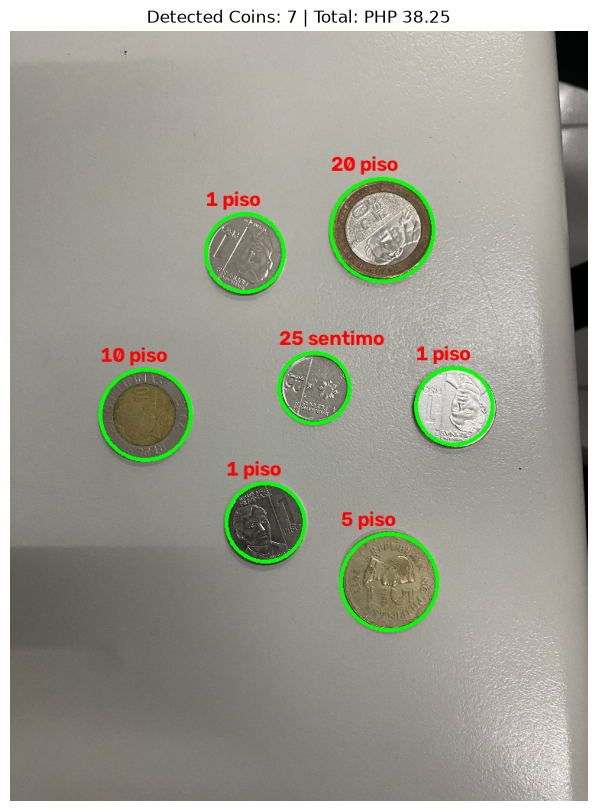

Total coins detected: 7

Breakdown:
  20 piso x 1 = PHP 20.00
  10 piso x 1 = PHP 10.00
  5 piso x 1 = PHP 5.00
  1 piso x 3 = PHP 3.00
  25 sentimo x 1 = PHP 0.25

TOTAL VALUE: PHP 38.25


In [18]:
output_img = image_rgb.copy()

for c in coin_results:
    x, y, r = c['x'], c['y'], c['r']
    cv2.circle(output_img, (x, y), r, (0, 255, 0), 3)
    cv2.putText(output_img, c['denom'], (x - r, y - r - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

plt.figure(figsize=(10, 10))
plt.imshow(output_img)
plt.title(f"Detected Coins: {len(coin_results)} | Total: PHP {sum(c['value'] for c in coin_results):.2f}")
plt.axis('off')
plt.show()

print(f"Total coins detected: {len(coin_results)}")
print("\nBreakdown:")
from collections import Counter
breakdown = Counter(c['denom'] for c in coin_results)
for denom, qty in sorted(breakdown.items(), key=lambda kv: -DENOM_VALUES[kv[0]]):
    print(f"  {denom} x {qty} = PHP {DENOM_VALUES[denom] * qty:.2f}")

total_value = sum(c['value'] for c in coin_results)
print(f"\nTOTAL VALUE: PHP {total_value:.2f}")

## Notes / If Using a Different Photo

If the counts or denominations come out wrong on a different image, try adjusting:
- **Hough parameters** in Section 2 (`minDist`, `param2`, `minRadius`, `maxRadius`) if coins are missed or double-counted
- **`BIMETALLIC_CHROMA_DIFF` / `BIMETALLIC_MIN_CHROMA`** in Section 3 if 10 piso / 20 piso coins aren't recognized as bi-metallic
- **`GOLD_CHROMA_THRESHOLD`** if a 5 piso coin is misread as 1 piso (or vice versa)
- **`SENTIMO_RADIUS_MAX`** if a small 1 piso coin is misread as 25 sentimo, or vice versa — this only works reliably when all coins in the photo are captured at the same scale/distance